In [ ]:
from google.colab import files
import pandas as pd

# Upload file
uploaded = files.upload()

Saving Data Inflasi.xlsx to Data Inflasi.xlsx


In [ ]:
import pandas as pd

data = pd.read_excel("/content/Data Inflasi.xlsx")
data.head()

,No,Periode,Data Inflasi
0,1,Desember 2002,0.0000
1,2,Januari 2003,0.0868
2,3,Februari 2003,0.0760
3,4,Maret 2003,0.0717
4,5,April 2003,0.0762


## **EDA**

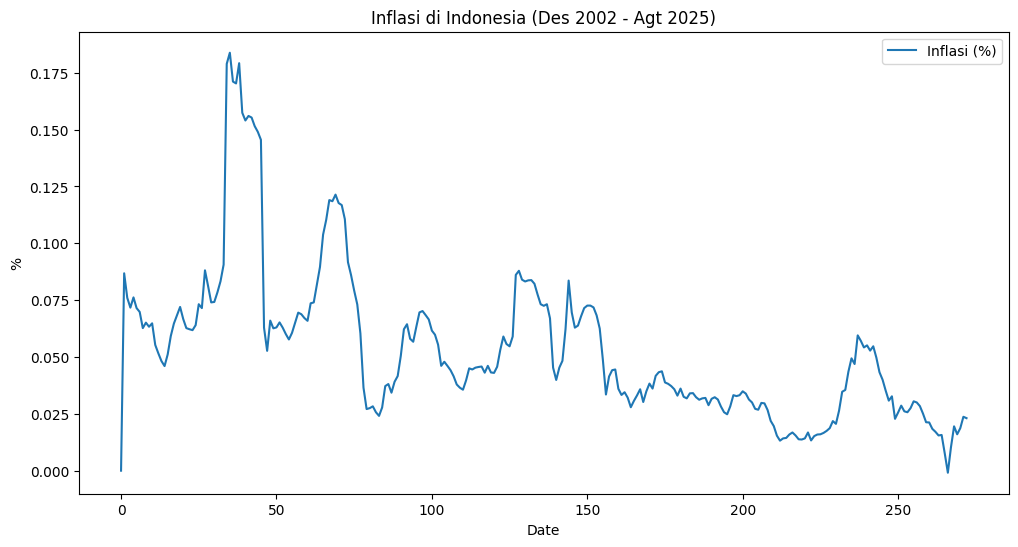

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data.index, data['Data Inflasi'], label= "Inflasi (%)")
plt.title("Inflasi di Indonesia (Des 2002 - Agt 2025)")
plt.xlabel("Date")
plt.ylabel("%")
plt.legend()
plt.show()

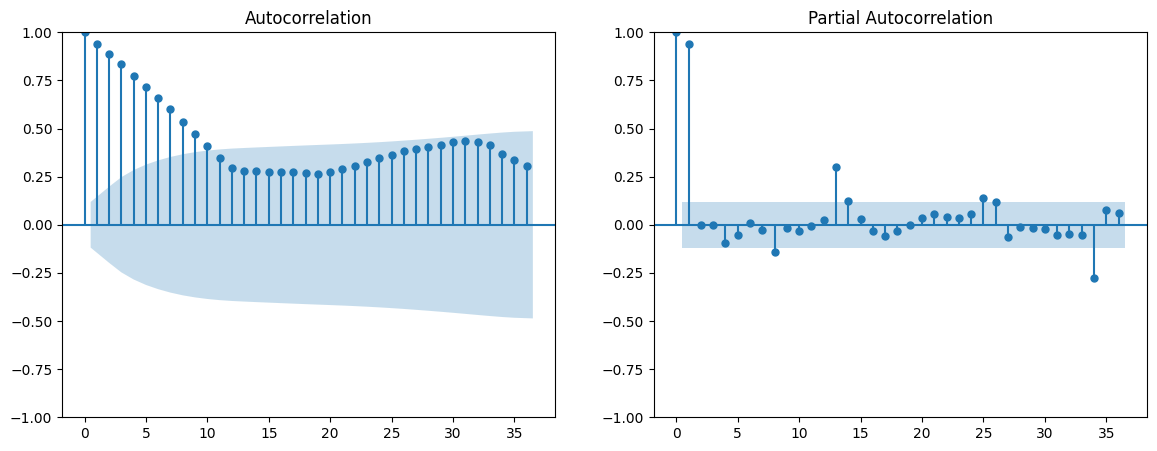

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2, figsize=(14,5))
plot_acf(data['Data Inflasi'], lags=36, ax=axes[0])
plot_pacf(data['Data Inflasi'], lags=36, ax=axes[1])
plt.show()

Jumlah outlier: 12
    No         Periode  Data Inflasi
34  35    Oktober 2005        0.1789
35  36   November 2005        0.1838
36  37   Desember 2005        0.1711
37  38    Januari 2006        0.1703
38  39   Februari 2006        0.1792
39  40      Maret 2006        0.1574
40  41      April 2006        0.1540
41  42        Mei 2006        0.1560
42  43       Juni 2006        0.1553
43  44       Juli 2006        0.1515
44  45    Agustus 2006        0.1490
45  46  September 2006        0.1455


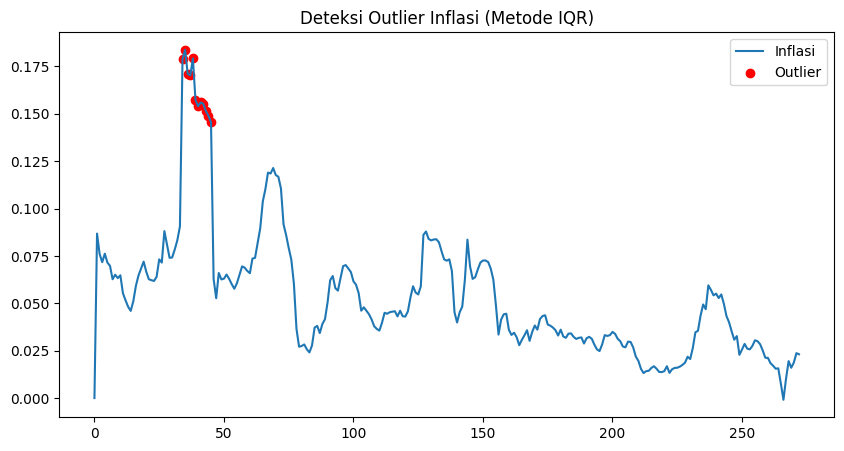

In [ ]:
# Hitung Q1 (kuartil bawah), Q3 (kuartil atas), dan IQR
Q1 = data['Data Inflasi'].quantile(0.25)
Q3 = data['Data Inflasi'].quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas bawah dan atas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Tandai data yang di luar batas sebagai outlier
outlier_mask = (data['Data Inflasi'] < batas_bawah) | (data['Data Inflasi'] > batas_atas)
outliers = data[outlier_mask]

print("Jumlah outlier:", outliers.shape[0])
print(outliers)

# Visualisasi
plt.figure(figsize=(10,5))
plt.plot(data.index, data['Data Inflasi'], label='Inflasi')
plt.scatter(outliers.index, outliers['Data Inflasi'], color='red', label='Outlier')
plt.legend()
plt.title("Deteksi Outlier Inflasi (Metode IQR)")
plt.show()

Terdapat short-term fluctuation, yaitu kelompok titik outlier berurutan

## **Boxcox**

**Jadikan Data > 0**

In [ ]:
data['y_pos'] = data['Data Inflasi'] + (abs(data['Data Inflasi'].min()) + 0.1)
data.head()

,No,Periode,Data Inflasi,y_pos
0,1,Desember 2002,0.0000,0.1009
1,2,Januari 2003,0.0868,0.1877
2,3,Februari 2003,0.0760,0.1769
3,4,Maret 2003,0.0717,0.1726
4,5,April 2003,0.0762,0.1771


In [ ]:
import numpy as np
np.sum(data['y_pos'] <= 0)

np.int64(0)

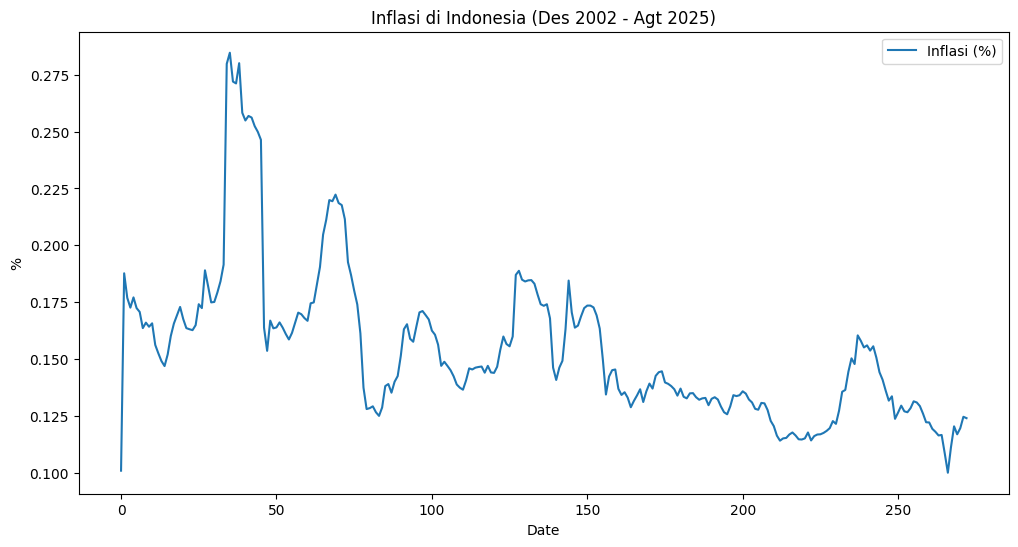

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data['y_pos'].index, data['y_pos'], label= "Inflasi (%)")
plt.title("Inflasi di Indonesia (Des 2002 - Agt 2025)")
plt.xlabel("Date")
plt.ylabel("%")
plt.legend()
plt.show()

### **Transformasi 1 Kali**

In [ ]:
from scipy import stats

lambda_opt = stats.boxcox_normmax(data['y_pos'], method='mle')
lambda_opt

np.float64(-1.5123265422155872)

In [ ]:
def boxcox_transform(y, lmbda):
    """
    Box-Cox transformation manual sesuai rumus:
      (y^λ - 1)/λ  , if λ != 0
      log(y)       , if λ == 0
    Syarat : y > 0
    """
    y = np.asarray(y)
    if np.any(y <= 0):
        raise ValueError("Box-Cox hanya bisa untuk y > 0. Shift data dulu agar positif.")

    if lmbda == 0:
        return np.log(y)
    else:
        return (np.power(y, lmbda) - 1) / lmbda

In [ ]:
data['y_trans'] = stats.boxcox(data['y_pos'], lmbda=lambda_opt)
data['y_trans'] = pd.Series(data['y_trans'], index=data['y_pos'].index) # jadikan dataframe
data.head()

,No,Periode,Data Inflasi,y_pos,y_trans
0,1,Desember 2002,0.0000,0.1009,-20.561253
1,2,Januari 2003,0.0868,0.1877,-7.639447
2,3,Februari 2003,0.0760,0.1769,-8.417716
3,4,Maret 2003,0.0717,0.1726,-8.761956
4,5,April 2003,0.0762,0.1771,-8.402215


In [ ]:
np.sum(data['y_trans'] <= 0)

np.int64(273)

## **Split Data**

In [ ]:
# Tentukan jumlah data test
test_size = 12

# Pisahkan data
train = data.iloc[:-test_size].copy()
test = data.iloc[-test_size:].copy()

print("Train size:", train.shape)
print("Test size:", test.shape)


Train size: (261, 5)
Test size: (12, 5)


In [ ]:
train = train.drop(columns=['No', 'Data Inflasi', 'y_pos'])
test = test.drop(columns=['No', 'Data Inflasi', 'y_pos'])

In [ ]:
y_test = test['y_trans']

## **Wavelet Transformation**

In [ ]:
import pywt
import numpy as np
import matplotlib.pyplot as plt

time_series = np.array(data['y_trans'])

# Dekompisi wavelet (level 1) menggunakan DB2
def wavelet_decompose(series, wavelet='db6', level=3):
    coeffs = pywt.wavedec(series, wavelet, level=level)
    y_A = pywt.waverec([coeffs[0], None, None, None], wavelet)
    y_D = pywt.waverec([None, coeffs[1], coeffs[2], coeffs[3]], wavelet)

    # Samakan panjang
    min_len = min(len(series), len(y_A), len(y_D))
    return y_A[:min_len], y_D[:min_len]

# Train
train_series = np.array(train['y_trans'])
train_yA, train_yD = wavelet_decompose(train_series)
train = train.iloc[:len(train_yA)]
train['y_A'] = train_yA
train['y_D'] = train_yD

# Test
test_series = np.array(test['y_trans'])
test_yA, test_yD = wavelet_decompose(test_series)
test = test.iloc[:len(test_yA)]
test['y_A'] = test_yA
test['y_D'] = test_yD

/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning: Level value of 3 is too high: all coefficients will experience boundary effects.
  warnings.warn(


## **ARIMA : Koefisien Detail**

Distribusi data dari koefisien aproksimasi dan detail pada subsekuens inflasi menunjukkan bahwa rentang fluktuasi koefisien aproksimasi relatif besar yang dapat merepresentasikan karakteristik gangguan dari inflasi. Sedangkan rentang fluktuasi koefisien detail lebih kecil yang dapat merepresentasikan karakteristik stabil dari inflasi.

### **ACF dan PACF**

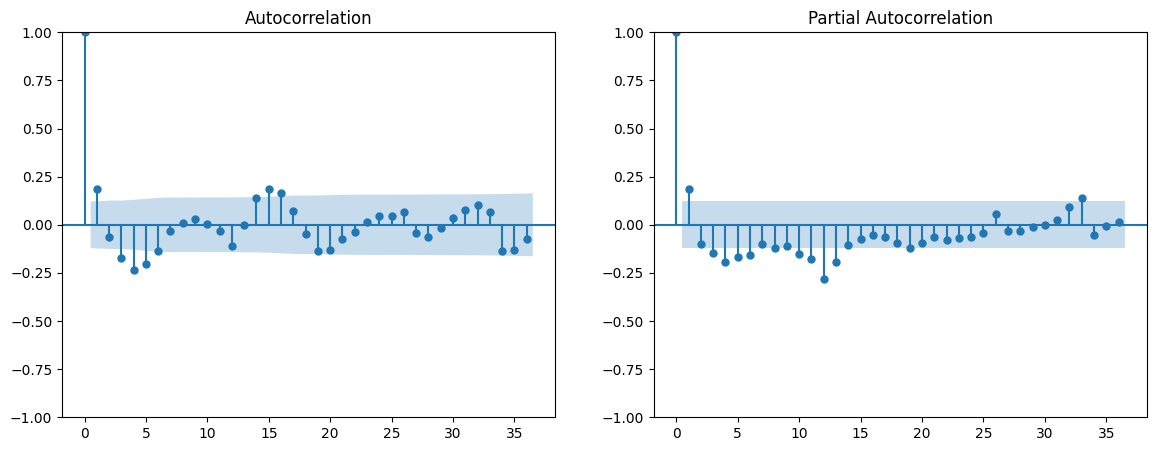

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2, figsize=(14,5))
plot_acf(train['y_D'], lags=36, ax=axes[0])
plot_pacf(train['y_D'], lags=36, ax=axes[1])
plt.show()


### **Stasioneritas Mean & Varians**

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train['y_D'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("✅ Data stasioner (tidak perlu differencing)")
else:
    print("⚠️ Data non-stasioner (perlu differencing)")

ADF Statistic: -9.580181395145624
p-value: 2.1689965735677978e-16
✅ Data stasioner (tidak perlu differencing)


In [ ]:
from statsmodels.stats.diagnostic import het_arch
import numpy as np

# Lakukan uji ARCH
arch_test = het_arch(train['y_D'])

print(f"LM Stat: {arch_test[0]:.4f}")
print(f"P-Value: {arch_test[1]:.4f}")

# Interpretasi
if arch_test[1] < 0.05:
    print("Varians tidak stasioner (ada efek ARCH / heteroskedastisitas).")
else:
    print("Varians stasioner (tidak ada bukti heteroskedastisitas).")

LM Stat: 57.5471
P-Value: 0.0000
Varians tidak stasioner (ada efek ARCH / heteroskedastisitas).


### **Checking**

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from scipy.stats import kstest, norm
from sklearn.metrics import mean_squared_error

def arima_assumption_check(y, pq_list, d=0):
    results = []

    for pq in pq_list:
        p, q = pq
        try:
            model = ARIMA(y, order=(p,d,q))
            fit = model.fit()
        except:
            continue

        # Prediksi & residual
        fitted_vals = fit.fittedvalues
        res = fit.resid

        # RMSE
        rmse_val = np.sqrt(mean_squared_error(y[d:], fitted_vals))

        # Normalitas (Kolmogorov-Smirnov)
        res_std = (res - np.mean(res)) / np.std(res)
        normality_p = kstest(res_std, 'norm').pvalue

        # Autokorelasi (Ljung-Box)
        lb_p = acorr_ljungbox(res, lags=[10], return_df=True)['lb_pvalue'].values[0]

        # Homoskedastisitas (Breusch-Pagan)
        # perlu model linear: resid ~ fitted
        import statsmodels.api as sm
        X = sm.add_constant(fitted_vals)
        bp_test = het_breuschpagan(res, X)
        homos_p = bp_test[1]  # p-value

        results.append({
            'Model': f'ARIMA({p},{d},{q})',
            'AIC': fit.aic,
            'RMSE': rmse_val,
            'Normality_p': normality_p,
            'Autocorr_p': lb_p,
            'Homos_p': homos_p
        })

    return pd.DataFrame(results)

In [ ]:
pq_list = [(1,1), (1,4), (1,5), (1,6), (3,1), (3,4), (3,5), (3,6), (4,1), (4,4), (4,5), (4,6)]
df_results = arima_assumption_check(train['y_D'], pq_list, d=0)
print(df_results)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWar

           Model         AIC      RMSE   Normality_p    Autocorr_p   Homos_p
0   ARIMA(1,0,1)  658.271159  0.886493  3.950767e-06  3.500794e-09  0.000653
1   ARIMA(1,0,4)  595.297700  0.839855  2.086413e-06  7.057182e-10  0.269437
2   ARIMA(1,0,5)  597.288606  0.839096  1.293021e-06  7.995078e-10  0.226214
3   ARIMA(1,0,6)  580.861729  0.922371  3.872338e-04  1.154042e-18  0.658956
4   ARIMA(3,0,1)  582.480658  0.843093  3.761697e-07  3.450377e-04  0.010347
5   ARIMA(3,0,4)  551.746758  0.878238  1.653187e-07  3.367813e-21  0.257757
6   ARIMA(3,0,5)  536.596038  0.817807  3.827858e-08  4.966313e-11  0.122483
7   ARIMA(3,0,6)  594.476065  0.833213  7.846060e-06  6.743837e-10  0.263264
8   ARIMA(4,0,1)  574.639485  0.842173  6.022937e-06  1.441214e-06  0.031209
9   ARIMA(4,0,4)  553.339605  0.990489  3.943666e-08  2.737765e-03  0.699720
10  ARIMA(4,0,5)  543.361826  0.841298  3.717711e-08  9.804780e-10  0.062529
11  ARIMA(4,0,6)  590.153887  0.855680  1.128067e-04  1.549848e-11  0.120247

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### **Pemodelan**

In [ ]:
import pandas as pd
import statsmodels.api as sm

def fit_arima_grid(y, p_values, q_values, d=0, show_summary=False):
    results = []

    for p in p_values:
        for q in q_values:
            try:
                model = sm.tsa.ARIMA(y, order=(p, d, q)).fit()
                results.append({
                    'p': p,
                    'd': d,
                    'q': q,
                    'AIC': model.aic,
                    'BIC': model.bic
                })
                print(f"✅ ARIMA({p},{d},{q}) fitted successfully.")
                if show_summary:
                    print(model.summary(), "\n")
            except Exception as e:
                print(f"❌ ARIMA({p},{d},{q}) failed: {e}")

    return pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)

# Penggunaan:
p_values = [1, 3, 4]
q_values = [1, 4, 5, 6]

summary_df = fit_arima_grid(train['y_D'], p_values, q_values, d=0, show_summary=False)
print("\n=== Hasil Ringkasan Model ARIMA ===")
print(summary_df)

✅ ARIMA(1,0,1) fitted successfully.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


✅ ARIMA(1,0,4) fitted successfully.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


✅ ARIMA(1,0,5) fitted successfully.


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


✅ ARIMA(4,0,4) fitted successfully.


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


✅ ARIMA(4,0,5) fitted successfully.
✅ ARIMA(4,0,6) fitted successfully.

=== Hasil Ringkasan Model ARIMA ===
    p  d  q         AIC         BIC
0   3  0  5  536.596038  572.241242
1   4  0  5  543.361826  582.571550
2   3  0  4  551.746758  583.827442
3   4  0  4  553.339605  588.984810
4   4  0  1  574.639485  599.591127
5   1  0  6  580.861729  612.942413
6   3  0  1  582.480658  603.867781
7   4  0  6  590.153887  632.928132
8   3  0  6  594.476065  633.685790
9   1  0  4  595.297700  620.249343
10  1  0  5  597.288606  625.804769
11  1  0  1  658.271159  672.529241


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### **Prediksi dgn Model Terbaik : ARIMA(4,0,4)**

**Prediksi Training**

In [ ]:
import statsmodels.api as sm

# Fit model ARIMA(3,0,5)
model_305 = sm.tsa.ARIMA(train['y_D'], order=(3, 0, 5)).fit()

# Prediksi untuk seluruh data training
train['y_L'] = model_305.predict(start=0, end=len(train['y_D'])-1)

print("\n=== Hasil Prediksi Data Training (ARIMA(4,0,4)) ===")
print(train['y_D'].head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== Hasil Prediksi Data Training (ARIMA(4,0,4)) ===
0   -8.482576
1    3.982967
2    2.542653
3    1.445717
4    1.110323
Name: y_D, dtype: float64


In [ ]:
test.shape

(12, 4)

**Prediksi Testing**

In [ ]:
# --- Prediksi 1 periode ke depan ---
# Periode berikutnya dimulai dari index len(train['y_D'])
forecast_1 = model_305.predict(start=len(train['y_D']), end=len(train['y_D']))

# --- Masukkan hasil prediksi ke test['y_L'] ---
test['y_L'] = np.nan
test.loc[test.index[0], 'y_L'] = forecast_1.values[0]

In [ ]:
test.head()

,Periode,y_trans,y_A,y_D,y_L
261,September 2024,-15.811877,-16.571343,0.759467,0.084797
262,Oktober 2024,-16.087112,-16.717228,0.630116,NaN
263,November 2024,-16.436500,-16.904715,0.468215,NaN
264,Desember 2024,-16.392167,-17.094141,0.701974,NaN
265,Januari 2025,-18.353912,-17.234576,-1.119335,NaN


### **Evaluasi**

**Evaluasi Training**

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Hitung MSE
mse = mean_squared_error(train['y_D'], train['y_L'])

# Akar kuadrat untuk dapat RMSE
rmse = np.sqrt(mse)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

MSE  : 0.6688
RMSE : 0.8178


### **Visualisasi**

**Data Aktual vs Forecast Training**

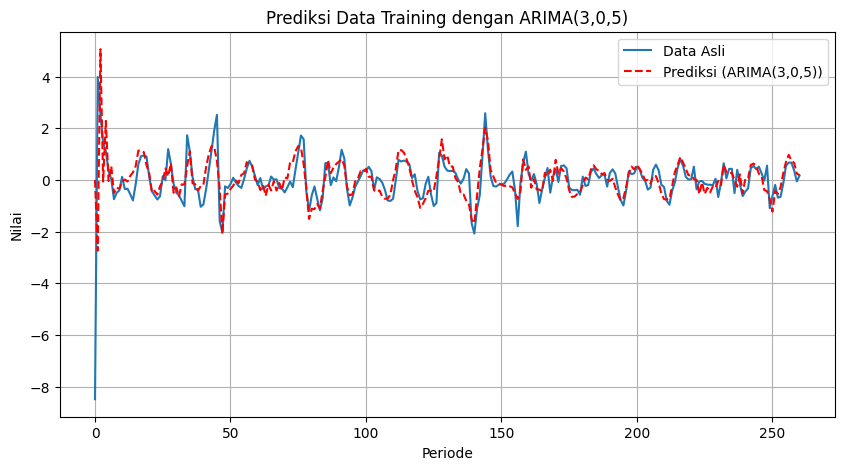

In [ ]:
# Visualisasi hasil prediksi vs data asli
plt.figure(figsize=(10,5))
plt.plot(train['y_D'], label='Data Asli')
plt.plot(train['y_L'], label='Prediksi (ARIMA(3,0,5))', linestyle='--', color='red')
plt.title('Prediksi Data Training dengan ARIMA(3,0,5)')
plt.xlabel('Periode')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

### **Residual**

In [ ]:
train['res_arima'] = train['y_D'] - train['y_L']
print(train['res_arima'].min())
print(train['res_arima'].max())

-8.482561168431005
6.716709377065178


/tmp/ipython-input-1157274533.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


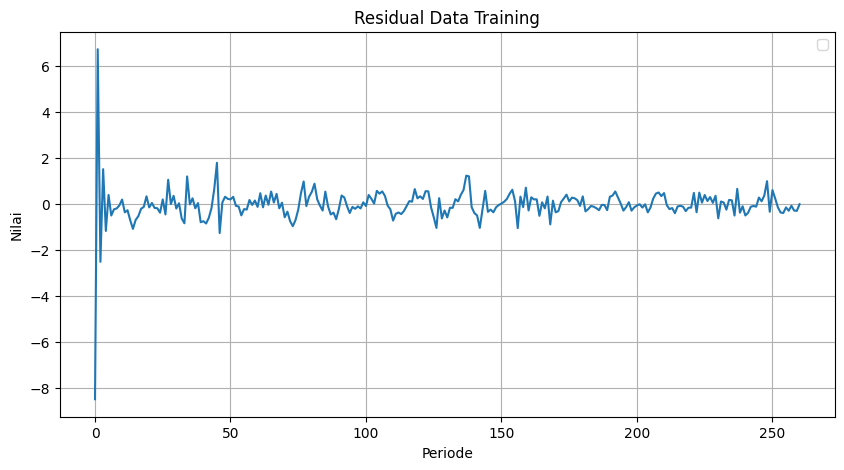

In [ ]:
# Visualisasi hasil prediksi vs data asli
plt.figure(figsize=(10,5))
plt.plot(train['res_arima'])
plt.title('Residual Data Training')
plt.xlabel('Periode')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

## **XGBoost : Koefisien Aproksimasi**

### **Persiapkan Data Train dan Test**

In [ ]:
train['y_NL'] = train['y_A'] + train['res_arima']

**ACF dan PACF Y_t**

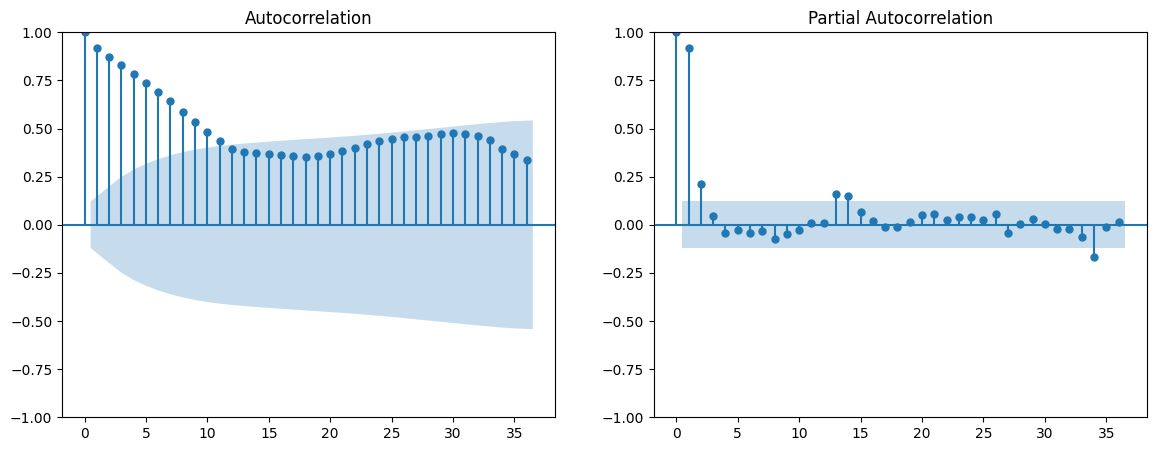

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2, figsize=(14,5))
plot_acf(train['y_trans'], lags=36, ax=axes[0])
plot_pacf(train['y_trans'], lags=36, ax=axes[1])
plt.show()

**ACF dan PACF Y_NL**

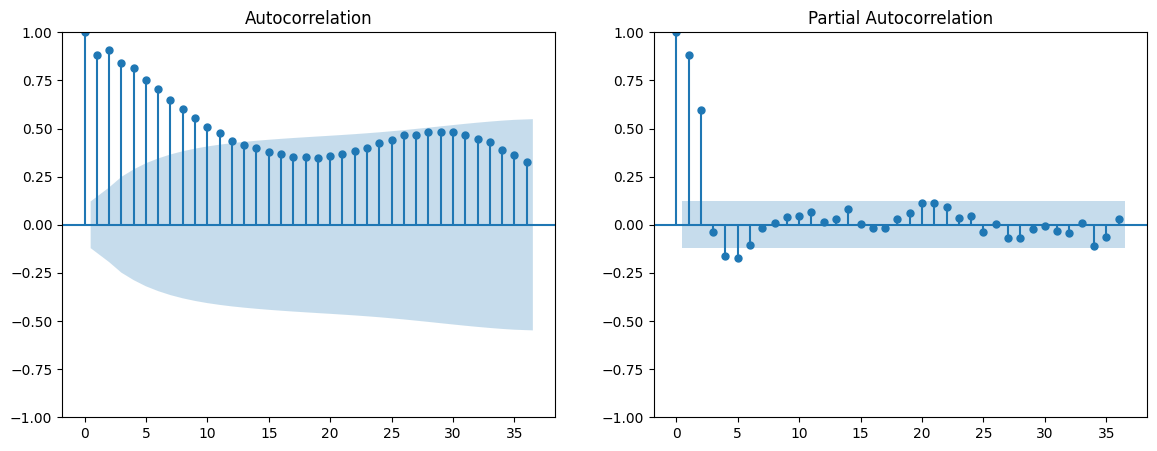

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2, figsize=(14,5))
plot_acf(train['y_NL'], lags=36, ax=axes[0])
plot_pacf(train['y_NL'], lags=36, ax=axes[1])
plt.show()

**Buat Full Data**

In [ ]:
y_NL_train = train['y_NL']
y_trans_train = train['y_trans']

In [ ]:
import pandas as pd

# Misal train dan test sudah ada kolom: y_t, y_L, y_NL, res_arima
# Gabungkan train + test supaya lag bisa terbentuk dari data sebelumnya
df_full = pd.concat([train, test], ignore_index=True)

# Tentukan jumlah lag
m, n = 9, 11 # m = lag y_t, n = lag y_NL

# Buat lag untuk y_t
for i in range(1, m + 1):
    df_full[f'y_trans_lag{i}'] = df_full['y_trans'].shift(i)

# Buat lag untuk y_NL
for j in range(1, n + 1):
    df_full[f'y_NL_lag{j}'] = df_full['y_NL'].shift(j)

# Drop baris awal yang belum punya lag
df_full = df_full.drop(columns=['y_trans', 'y_A', 'y_D', 'y_NL', 'res_arima'])
df_full = df_full.dropna().reset_index(drop=True)

# Cek hasil
df_full.tail()

,Periode,y_L,y_trans_lag1,y_trans_lag2,y_trans_lag3,y_trans_lag4,y_trans_lag5,y_trans_lag6,y_trans_lag7,y_trans_lag8,...,y_NL_lag2,y_NL_lag3,y_NL_lag4,y_NL_lag5,y_NL_lag6,y_NL_lag7,y_NL_lag8,y_NL_lag9,y_NL_lag10,y_NL_lag11
246,Mei 2024,0.751688,-13.655042,-13.572737,-14.078690,-14.396783,-14.325116,-13.889753,-14.414789,-14.933855,...,-14.273160,-14.344839,-14.118120,-13.787782,-13.459984,-13.189867,-14.183767,-12.788280,-13.133612,-12.977053
247,Juni 2024,0.659347,-13.923805,-13.655042,-13.572737,-14.078690,-14.396783,-14.325116,-13.889753,-14.414789,...,-14.625766,-14.273160,-14.344839,-14.118120,-13.787782,-13.459984,-13.189867,-14.183767,-12.788280,-13.133612
248,Juli 2024,0.247871,-14.505357,-13.923805,-13.655042,-13.572737,-14.078690,-14.396783,-14.325116,-13.889753,...,-14.675492,-14.625766,-14.273160,-14.344839,-14.118120,-13.787782,-13.459984,-13.189867,-14.183767,-12.788280
249,Agustus 2024,0.185821,-15.224267,-14.505357,-13.923805,-13.655042,-13.572737,-14.078690,-14.396783,-14.325116,...,-15.164704,-14.675492,-14.625766,-14.273160,-14.344839,-14.118120,-13.787782,-13.459984,-13.189867,-14.183767
250,September 2024,0.084797,-15.243946,-15.224267,-14.505357,-13.923805,-13.655042,-13.572737,-14.078690,-14.396783,...,-15.472138,-15.164704,-14.675492,-14.625766,-14.273160,-14.344839,-14.118120,-13.787782,-13.459984,-13.189867


**Split Train dan Test**

In [ ]:
# Panjang test
len_test = 1

# df_test = bagian akhir
test = df_full.tail(len_test).reset_index(drop=True)

# df_train = sisanya (bagian awal)
train = df_full.iloc[:-len_test].reset_index(drop=True)

In [ ]:
train['y_trans'] = y_trans_train

In [ ]:
test.head()

,Periode,y_L,y_trans_lag1,y_trans_lag2,y_trans_lag3,y_trans_lag4,y_trans_lag5,y_trans_lag6,y_trans_lag7,y_trans_lag8,...,y_NL_lag2,y_NL_lag3,y_NL_lag4,y_NL_lag5,y_NL_lag6,y_NL_lag7,y_NL_lag8,y_NL_lag9,y_NL_lag10,y_NL_lag11
0,September 2024,0.084797,-15.243946,-15.224267,-14.505357,-13.923805,-13.655042,-13.572737,-14.07869,-14.396783,...,-15.472138,-15.164704,-14.675492,-14.625766,-14.27316,-14.344839,-14.11812,-13.787782,-13.459984,-13.189867


In [ ]:
train.head()

,Periode,y_L,y_trans_lag1,y_trans_lag2,y_trans_lag3,y_trans_lag4,y_trans_lag5,y_trans_lag6,y_trans_lag7,y_trans_lag8,...,y_NL_lag3,y_NL_lag4,y_NL_lag5,y_NL_lag6,y_NL_lag7,y_NL_lag8,y_NL_lag9,y_NL_lag10,y_NL_lag11,y_trans
0,November 2003,0.015581,-9.361675,-9.500469,-9.334293,-9.556883,-8.921029,-8.778493,-8.402215,-8.761956,...,-9.037576,-9.047439,-9.456542,-8.735649,-10.687522,-8.699972,-13.475086,-4.905706,-20.561238,-20.561253
1,Desember 2003,-0.062763,-10.297794,-9.361675,-9.500469,-9.334293,-9.556883,-8.921029,-8.778493,-8.402215,...,-9.160004,-9.037576,-9.047439,-9.456542,-8.735649,-10.687522,-8.699972,-13.475086,-4.905706,-7.639447
2,Januari 2004,0.158491,-10.702398,-10.297794,-9.361675,-9.500469,-9.334293,-9.556883,-8.921029,-8.778493,...,-9.297083,-9.160004,-9.037576,-9.047439,-9.456542,-8.735649,-10.687522,-8.699972,-13.475086,-8.417716
3,Februari 2004,0.293727,-11.096569,-10.702398,-10.297794,-9.361675,-9.500469,-9.334293,-9.556883,-8.921029,...,-10.313375,-9.297083,-9.160004,-9.037576,-9.047439,-9.456542,-8.735649,-10.687522,-8.699972,-8.761956
4,Maret 2004,0.525729,-11.363889,-11.096569,-10.702398,-10.297794,-9.361675,-9.500469,-9.334293,-9.556883,...,-10.639635,-10.313375,-9.297083,-9.160004,-9.037576,-9.047439,-9.456542,-8.735649,-10.687522,-8.402215


In [ ]:
print(train.shape)
print(test.shape)

(250, 23)
(1, 22)


### **EDA Feature XGBoost**

**Korelasi**

In [ ]:
import plotly.express as px

# Pilih hanya data numerik
numeric = train.select_dtypes(include=["int64", "float64", "int32"])

# Hitung korelasi
corr = numeric.corr()

# Plot heatmap interaktif
fig = px.imshow(
    corr,
    text_auto=".2f",  # tampilkan angka di dalam kotak
    color_continuous_scale="YlGnBu",
    aspect="auto",
    title="Heatmap Korelasi Variabel Numerik"
)

fig.update_layout(width=800, height=600)  # atur ukuran
fig.show()

### **Pemodelan**

In [ ]:
# Fitur
y_trans_lags = [f'y_trans_lag{i}' for i in range(1, 10)]  # lag 1-9
y_NL_lags = [f'y_NL_lag{i}' for i in range(1, 12)]       # lag 1-11
X_cols = y_trans_lags + y_NL_lags + ['y_L']              # tambahkan prediksi linear

# Pisahkan fitur (X) dan target (y)
y_train = train['y_trans']
X_train = train[X_cols]

X_train['y_L'] = X_train['y_L'].astype(float)

/tmp/ipython-input-4098706291.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
X_train.head()

,y_trans_lag1,y_trans_lag2,y_trans_lag3,y_trans_lag4,y_trans_lag5,y_trans_lag6,y_trans_lag7,y_trans_lag8,y_trans_lag9,y_NL_lag1,...,y_NL_lag3,y_NL_lag4,y_NL_lag5,y_NL_lag6,y_NL_lag7,y_NL_lag8,y_NL_lag9,y_NL_lag10,y_NL_lag11,y_L
0,-9.361675,-9.500469,-9.334293,-9.556883,-8.921029,-8.778493,-8.402215,-8.761956,-8.417716,-9.297083,...,-9.037576,-9.047439,-9.456542,-8.735649,-10.687522,-8.699972,-13.475086,-4.905706,-20.561238,0.015581
1,-10.297794,-9.361675,-9.500469,-9.334293,-9.556883,-8.921029,-8.778493,-8.402215,-8.761956,-10.313375,...,-9.160004,-9.037576,-9.047439,-9.456542,-8.735649,-10.687522,-8.699972,-13.475086,-4.905706,-0.062763
2,-10.702398,-10.297794,-9.361675,-9.500469,-9.334293,-9.556883,-8.921029,-8.778493,-8.402215,-10.639635,...,-9.297083,-9.160004,-9.037576,-9.047439,-9.456542,-8.735649,-10.687522,-8.699972,-13.475086,0.158491
3,-11.096569,-10.702398,-10.297794,-9.361675,-9.500469,-9.334293,-9.556883,-8.921029,-8.778493,-11.255060,...,-10.313375,-9.297083,-9.160004,-9.037576,-9.047439,-9.456542,-8.735649,-10.687522,-8.699972,0.293727
4,-11.363889,-11.096569,-10.702398,-10.297794,-9.361675,-9.500469,-9.334293,-9.556883,-8.921029,-11.657615,...,-10.639635,-10.313375,-9.297083,-9.160004,-9.037576,-9.047439,-9.456542,-8.735649,-10.687522,0.525729


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import xgboost as xgb

param_grid = {
    'n_estimators': [200, 500, 800],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=3)

model = xgb.XGBRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_mean_absolute_percentage_error',
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best Score (MAPE GridSearchCV):", -grid_search.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best Score (MAPE GridSearchCV): 0.09685506354475377


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prediksi train
best_model = grid_search.best_estimator_
y_pred_train = best_model.predict(X_train)

# Metrics
mape_train = np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100
mae_train  = mean_absolute_error(y_train, y_pred_train)
mse_train  = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train   = r2_score(y_train, y_pred_train)

# Cetak hasil
print("MAPE  Train:", mape_train)
print("MAE   Train:", mae_train)
print("MSE   Train:", mse_train)
print("RMSE  Train:", rmse_train)
print("R²    Train:", r2_train)

MAPE  Train: 5.882452314703433
MAE   Train: 0.5338115323567456
MSE   Train: 0.5069164531715151
RMSE  Train: 0.7119806550542754
R²    Train: 0.9444972442463154


In [ ]:
# Pisahkan fitur (X) dan target (y)
test['y_L'] = test['y_L'].astype(float)
X_test = test.drop(columns='Periode')
X_test = X_test[X_train.columns]

In [ ]:
# Evaluasi Test
from sklearn.metrics import mean_absolute_error, r2_score

best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_test

array([-13.049402], dtype=float32)

In [ ]:
# Prediksi test
y_pred_test = best_model.predict(X_test)

# Ambil prediksi pertama
y_pred_first = [y_pred_test[0]]      # <-- ambil elemen pertama
y_true_first = [y_test.iloc[0]]      # <-- ambil target pertama

# Inverse Box-Cox
from scipy.special import inv_boxcox
y_pred_first_inv = inv_boxcox(y_pred_first, lambda_opt)
y_true_first_inv = inv_boxcox(y_true_first, lambda_opt)

# Evaluasi
from sklearn.metrics import mean_squared_error
import numpy as np

mse_first = mean_squared_error(y_true_first_inv, y_pred_first_inv)
rmse_first = np.sqrt(mse_first)

print(f"MSE (baris pertama)  : {mse_first:.4f}")
print(f"RMSE (baris pertama) : {rmse_first:.4f}")


MSE (baris pertama)  : 0.0002
RMSE (baris pertama) : 0.0154


## **Forecast Semua Test Secara Iterative**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



✅ Training data shape: X=(250, 21), y=(250,)
✅ Model XGBoost selesai dilatih.

🔄 Melakukan prediksi multi-step...
Step 1/12: y_pred=-15.3843, y_L=0.3272, y_NL=-15.7114
Step 2/12: y_pred=-16.3400, y_L=-0.0638, y_NL=-16.2762
Step 3/12: y_pred=-16.7026, y_L=-0.1873, y_NL=-16.5152
Step 4/12: y_pred=-16.6499, y_L=-0.4314, y_NL=-16.2185
Step 5/12: y_pred=-16.6860, y_L=-0.4581, y_NL=-16.2279
Step 6/12: y_pred=-16.5884, y_L=-0.3821, y_NL=-16.2063
Step 7/12: y_pred=-16.5954, y_L=-0.2806, y_NL=-16.3148
Step 8/12: y_pred=-16.5379, y_L=0.0346, y_NL=-16.5724
Step 9/12: y_pred=-16.6514, y_L=0.1160, y_NL=-16.7674
Step 10/12: y_pred=-16.6081, y_L=0.4255, y_NL=-17.0336
Step 11/12: y_pred=-16.7345, y_L=0.3253, y_NL=-17.0598
Step 12/12: y_pred=-16.5685, y_L=0.4403, y_NL=-17.0089
✅ Multi-step forecast selesai!

📌 Hasil Prediksi 12 Bulan (Skala Asli):
     y_true_inv  y_pred_inv
261      0.1193    0.121393
262      0.1180    0.116836
263      0.1164    0.115218
264      0.1166    0.115449
265      0.1085  

/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning:

Level value of 3 is too high: all coefficients will experience boundary effects.

/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning:

Level value of 3 is too high: all coefficients will experience boundary effects.

/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning:

Level value of 3 is too high: all coefficients will experience boundary effects.

/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning:

Level value of 3 is too high: all coefficients will experience boundary effects.

/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning:

Level value of 3 is too high: all coefficients will experience boundary effects.

/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning:

Level value of 3 is too high: all coefficients will experience boundary effects.

/usr/local/lib/python3.12/dist-packages/

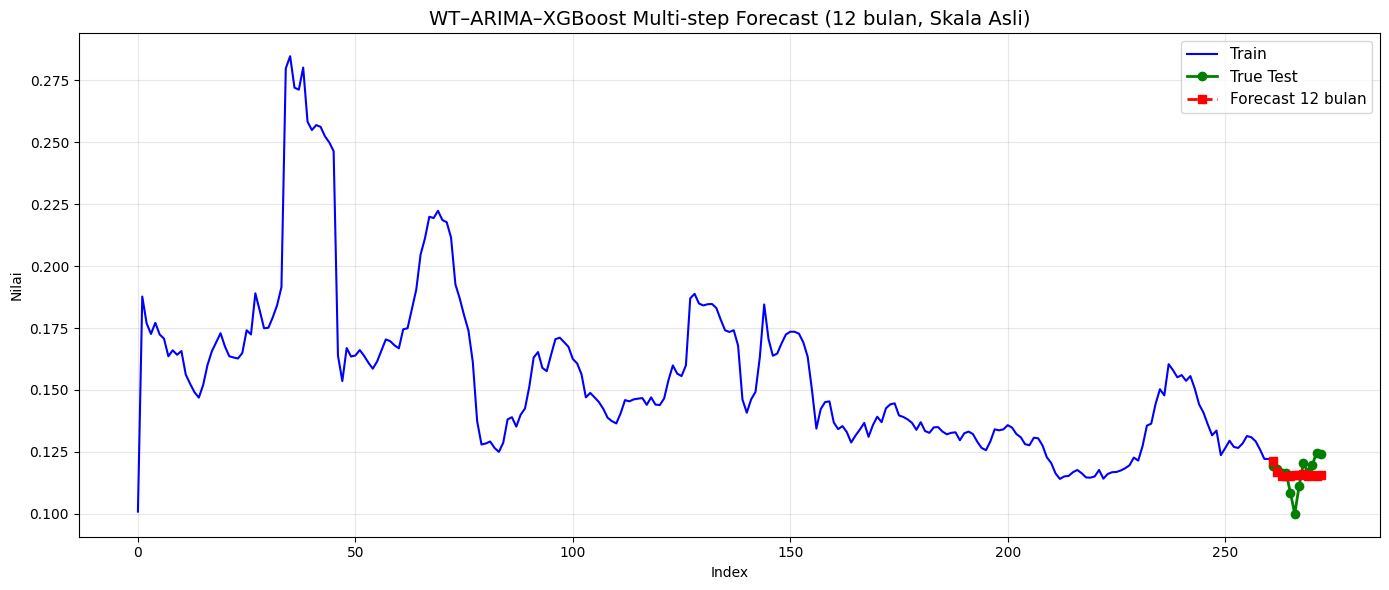

In [ ]:
# =========================================
# 1️⃣ SPLIT DATA
# =========================================
test_size = 12
train = data.iloc[:-test_size].copy()
test = data.iloc[-test_size:].copy()

# =========================================
# 2️⃣ WAVELET TRANSFORMATION
# =========================================
def wavelet_decompose(series, wavelet='db6', level=3):
    coeffs = pywt.wavedec(series, wavelet, level=level)
    y_A = pywt.waverec([coeffs[0], None, None, None], wavelet)
    y_D = pywt.waverec([None, coeffs[1], coeffs[2], coeffs[3]], wavelet)
    min_len = min(len(series), len(y_A), len(y_D))
    return y_A[:min_len], y_D[:min_len]

train['y_A'], train['y_D'] = wavelet_decompose(train['y_trans'])

# =========================================
# 3️⃣ ARIMA FIT (DETAIL PART)
# =========================================
model_arima = sm.tsa.ARIMA(train['y_D'], order=(4,0,4)).fit()
train['y_L'] = model_arima.fittedvalues

# Multi-step forecast ARIMA (12 bulan) - ini akan digunakan di XGBoost
forecast_arima = model_arima.forecast(steps=test_size)

# =========================================
# 4️⃣ HITUNG RESIDUAL DAN BENTUK NONLINEAR PART
# =========================================
train['res_arima'] = train['y_D'] - train['y_L']
train['y_NL'] = train['y_A'] + train['res_arima']

# =========================================
# 5️⃣ PREPARE DATA UNTUK XGBOOST
# =========================================
m, n = 9, 11  # lag untuk y_trans dan y_NL

# Buat lag features di training data
for i in range(1, m+1):
    train[f'y_trans_lag{i}'] = train['y_trans'].shift(i)
for j in range(1, n+1):
    train[f'y_NL_lag{j}'] = train['y_NL'].shift(j)

# Drop missing values dari lag
train_clean = train.dropna().copy()

# Prepare features dan target
feature_cols = [c for c in train_clean.columns if 'lag' in c or c == 'y_L']
X_train = train_clean[feature_cols]
y_train = train_clean['y_trans']

print(f"✅ Training data shape: X={X_train.shape}, y={y_train.shape}")

# =========================================
# 6️⃣ FIT XGBOOST
# =========================================
model_xgb = xgb.XGBRegressor(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=42
)
model_xgb.fit(X_train, y_train)
print("✅ Model XGBoost selesai dilatih.")

# =========================================
# 7️⃣ MULTI-STEP FORECAST (XGBoost)
# =========================================
predictions = []

# Inisialisasi dengan data terakhir dari training
# Ambil lag y_trans dari train (data asli)
last_y_trans = train['y_trans'].iloc[-(m):].values[::-1]  # m nilai terakhir, dibalik

# Ambil lag y_NL dari train
last_y_NL = train['y_NL'].iloc[-(n):].values[::-1]  # n nilai terakhir, dibalik

# History untuk wavelet decomposition (butuh cukup data)
wavelet_history = train['y_trans'].iloc[-50:].values.tolist()  # simpan 50 nilai terakhir

print("\n🔄 Melakukan prediksi multi-step...")
for step in range(test_size):
    # Siapkan input features
    input_features = {}

    # Lag dari y_trans
    for i in range(1, m+1):
        input_features[f'y_trans_lag{i}'] = last_y_trans[i-1]

    # Lag dari y_NL
    for j in range(1, n+1):
        input_features[f'y_NL_lag{j}'] = last_y_NL[j-1]

    # y_L dari ARIMA forecast
    input_features['y_L'] = forecast_arima.iloc[step]

    # Buat DataFrame untuk prediksi
    X_input = pd.DataFrame([input_features])[feature_cols]

    # Prediksi
    y_pred = model_xgb.predict(X_input)[0]
    predictions.append(y_pred)

    # Update history untuk step berikutnya
    # Update y_trans lags
    last_y_trans = np.concatenate([[y_pred], last_y_trans[:-1]])

    # Update y_NL dengan rekonstruksi wavelet
    # Tambahkan prediksi ke history
    wavelet_history.append(y_pred)

    # Dekomposisi wavelet dari history terbaru
    history_array = np.array(wavelet_history[-50:])  # gunakan 50 data terakhir
    y_A_new, y_D_new = wavelet_decompose(pd.Series(history_array))

    # Ambil komponen approx terbaru
    y_A_current = y_A_new[-1]

    # Hitung residual ARIMA untuk step ini
    # y_D untuk data baru tidak diketahui, tapi kita punya y_L dari ARIMA
    # res_arima = y_D - y_L, tapi y_D tidak diketahui
    # Aproksimasi: res_arima = y_pred - y_L - y_A
    res_arima_current = y_pred - forecast_arima.iloc[step] - y_A_current

    # Hitung y_NL baru
    y_NL_new = y_A_current + res_arima_current

    # Update y_NL lags
    last_y_NL = np.concatenate([[y_NL_new], last_y_NL[:-1]])

    print(f"Step {step+1}/12: y_pred={y_pred:.4f}, y_L={forecast_arima.iloc[step]:.4f}, y_NL={y_NL_new:.4f}")

print("✅ Multi-step forecast selesai!")

# =========================================
# 8️⃣ INVERSE BOX-COX
# =========================================
y_pred_inv = inv_boxcox(np.array(predictions), lambda_opt)
y_true_inv = inv_boxcox(test['y_trans'].values, lambda_opt)

df_forecast = pd.DataFrame({
    'y_true_inv': y_true_inv,
    'y_pred_inv': y_pred_inv
}, index=test.index)

print("\n📌 Hasil Prediksi 12 Bulan (Skala Asli):")
print(df_forecast)

# =========================================
# 9️⃣ EVALUASI
# =========================================
mse = mean_squared_error(df_forecast['y_true_inv'], df_forecast['y_pred_inv'])
rmse = np.sqrt(mse)
mape = np.mean(np.abs((df_forecast['y_true_inv'] - df_forecast['y_pred_inv']) / df_forecast['y_true_inv'])) * 100

print("\n📊 === Hasil Multi-step Forecast (12 bulan) ===")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# =========================================
# 🔟 VISUALISASI (Skala Asli)
# =========================================
plt.figure(figsize=(14,6))
plt.plot(train.index, inv_boxcox(train['y_trans'], lambda_opt),
         label='Train', color='blue', linewidth=1.5)
plt.plot(test.index, df_forecast['y_true_inv'],
         label='True Test', color='green', linewidth=2, marker='o')
plt.plot(test.index, df_forecast['y_pred_inv'],
         label='Forecast 12 bulan', color='red', linewidth=2,
         linestyle='--', marker='s')
plt.legend(loc='best', fontsize=11)
plt.title('WT–ARIMA–XGBoost Multi-step Forecast (12 bulan, Skala Asli)', fontsize=14)
plt.xlabel('Index')
plt.ylabel('Nilai')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

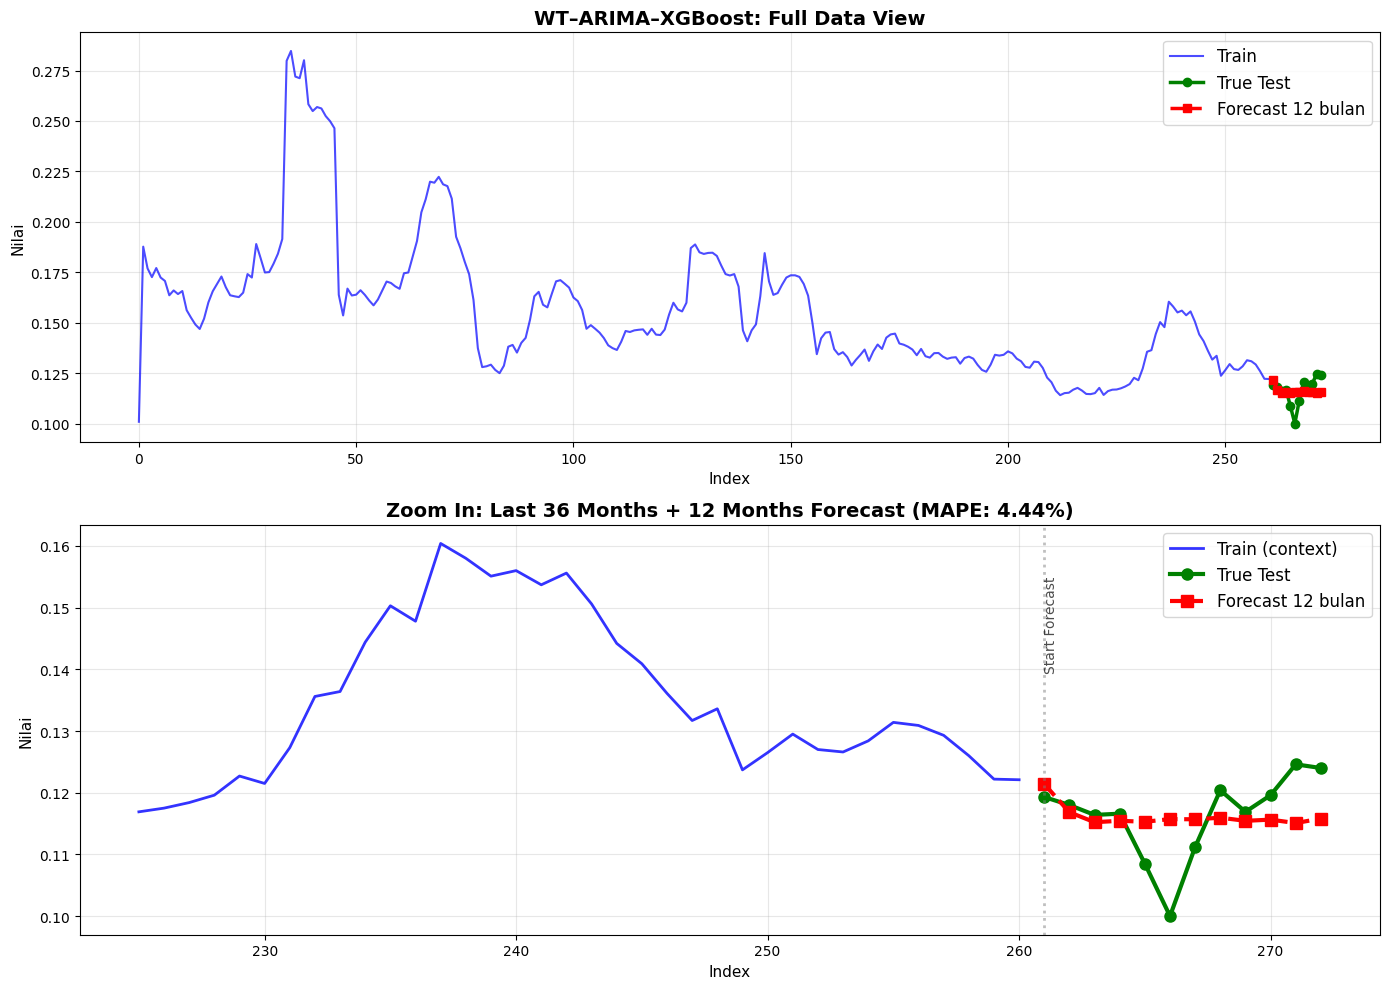

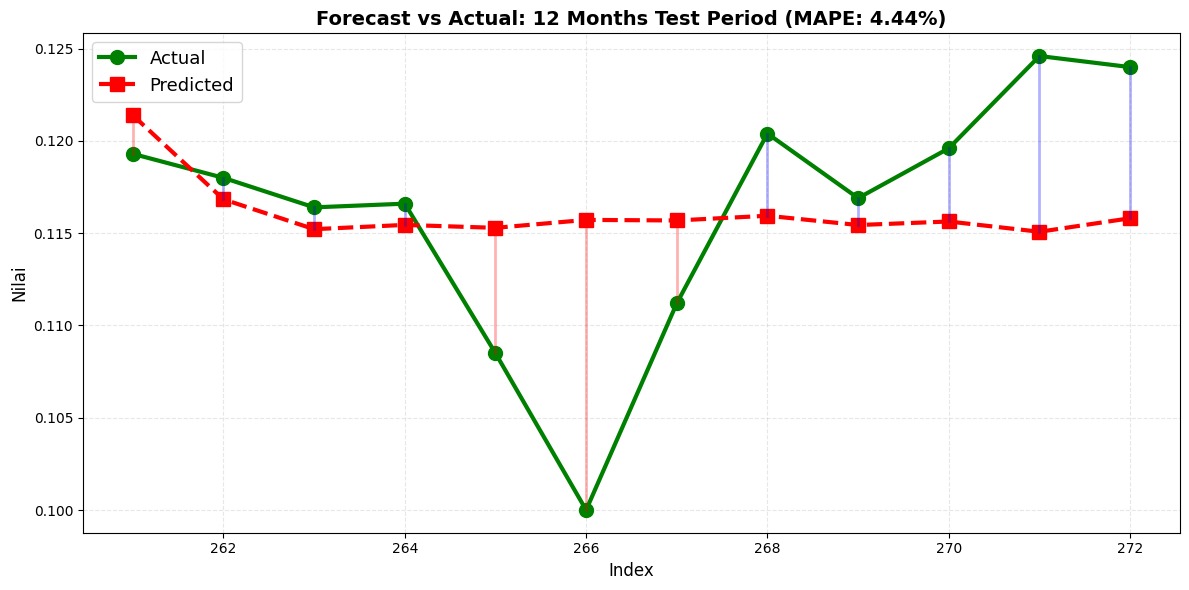

In [ ]:
#=========================================
# 🔟 VISUALISASI (Skala Asli)
# =========================================

# Plot 1: Full view
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: Semua data
axes[0].plot(train.index, inv_boxcox(train['y_trans'], lambda_opt),
             label='Train', color='blue', linewidth=1.5, alpha=0.7)
axes[0].plot(test.index, df_forecast['y_true_inv'],
             label='True Test', color='green', linewidth=2.5, marker='o', markersize=6)
axes[0].plot(test.index, df_forecast['y_pred_inv'],
             label='Forecast 12 bulan', color='red', linewidth=2.5,
             linestyle='--', marker='s', markersize=6)
axes[0].legend(loc='best', fontsize=12)
axes[0].set_title('WT–ARIMA–XGBoost: Full Data View', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Index', fontsize=11)
axes[0].set_ylabel('Nilai', fontsize=11)
axes[0].grid(alpha=0.3)

# Subplot 2: Zoom in ke 24-36 bulan terakhir (termasuk test)
n_context = 36  # tampilkan 36 bulan terakhir untuk konteks
train_context = train.iloc[-n_context:] if len(train) > n_context else train

axes[1].plot(train_context.index, inv_boxcox(train_context['y_trans'], lambda_opt),
             label='Train (context)', color='blue', linewidth=2, alpha=0.8)
axes[1].plot(test.index, df_forecast['y_true_inv'],
             label='True Test', color='green', linewidth=3, marker='o', markersize=8)
axes[1].plot(test.index, df_forecast['y_pred_inv'],
             label='Forecast 12 bulan', color='red', linewidth=3,
             linestyle='--', marker='s', markersize=8)
axes[1].axvline(x=test.index[0], color='gray', linestyle=':', linewidth=2, alpha=0.5)
axes[1].text(test.index[0], axes[1].get_ylim()[1]*0.95, 'Start Forecast',
            rotation=90, verticalalignment='top', fontsize=10, alpha=0.7)
axes[1].legend(loc='best', fontsize=12)
axes[1].set_title(f'Zoom In: Last {n_context} Months + 12 Months Forecast (MAPE: {mape:.2f}%)',
                 fontsize=14, fontweight='bold')
axes[1].set_xlabel('Index', fontsize=11)
axes[1].set_ylabel('Nilai', fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Plot tambahan: Hanya test period (super zoom)
plt.figure(figsize=(12, 6))
plt.plot(test.index, df_forecast['y_true_inv'],
         label='Actual', color='green', linewidth=3, marker='o', markersize=10)
plt.plot(test.index, df_forecast['y_pred_inv'],
         label='Predicted', color='red', linewidth=3,
         linestyle='--', marker='s', markersize=10)

# Tambahkan error bars
errors = df_forecast['y_pred_inv'] - df_forecast['y_true_inv']
for i, (idx, err) in enumerate(zip(test.index, errors)):
    color = 'red' if err > 0 else 'blue'
    plt.plot([idx, idx], [df_forecast['y_true_inv'].iloc[i], df_forecast['y_pred_inv'].iloc[i]],
             color=color, alpha=0.3, linewidth=2)

plt.legend(loc='best', fontsize=13)
plt.title(f'Forecast vs Actual: 12 Months Test Period (MAPE: {mape:.2f}%)',
         fontsize=14, fontweight='bold')
plt.xlabel('Index', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

   4.6 EVALUASI MODEL HYBRID WAVELET–ARIMA–XGBOOST

📊 4.6.1 EVALUASI TRAINING SET
------------------------------------------------------------
MSE   : 0.000000
RMSE  : 0.000044
MAE   : 0.000025
MAPE  : 0.02%
R²    : 1.0000

📊 4.6.2 EVALUASI TESTING SET (12 BULAN)
------------------------------------------------------------
MSE   : 0.000043
RMSE  : 0.006566
MAE   : 0.005015
MAPE  : 4.44%
R²    : 0.0066

📋 4.6.3 TABEL PERBANDINGAN METRIK TRAIN vs TEST
------------------------------------------------------------
  Metrik     Training  Testing
     MSE 1.935542e-09 0.000043
    RMSE 4.399480e-05 0.006566
     MAE 2.516543e-05 0.005015
MAPE (%) 1.531387e-02 4.439178
      R² 9.999983e-01 0.006612

📋 4.6.4 TABEL HASIL FORECAST 12 BULAN KE DEPAN
------------------------------------------------------------
 Bulan_Ke  Index  Actual  Forecast     Error  Abs_Error   APE (%)
        1    261  0.1193  0.121393  0.002093   0.002093  1.754210
        2    262  0.1180  0.116836 -0.001164   0.001164  0

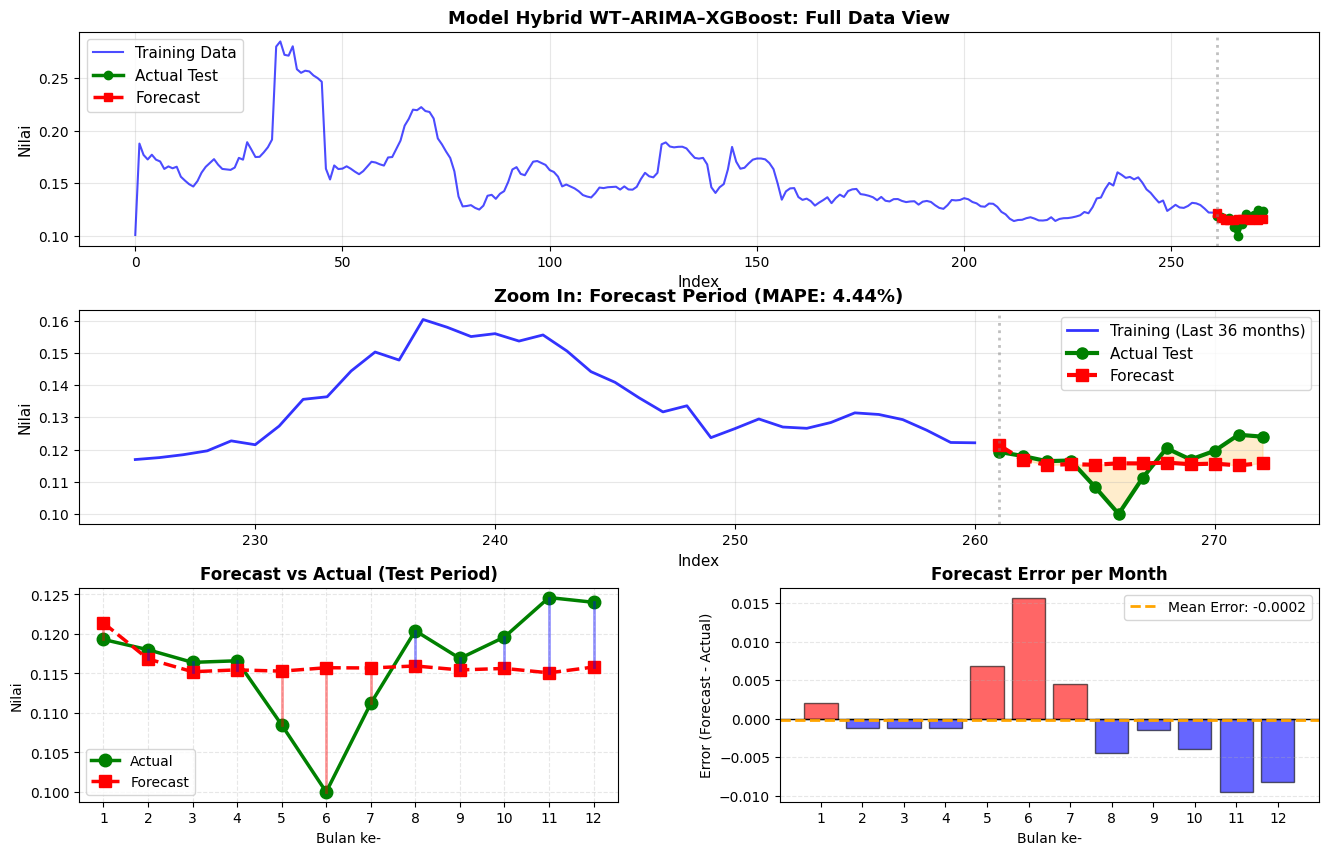


📊 4.6.6 ANALISIS RESIDUAL
------------------------------------------------------------


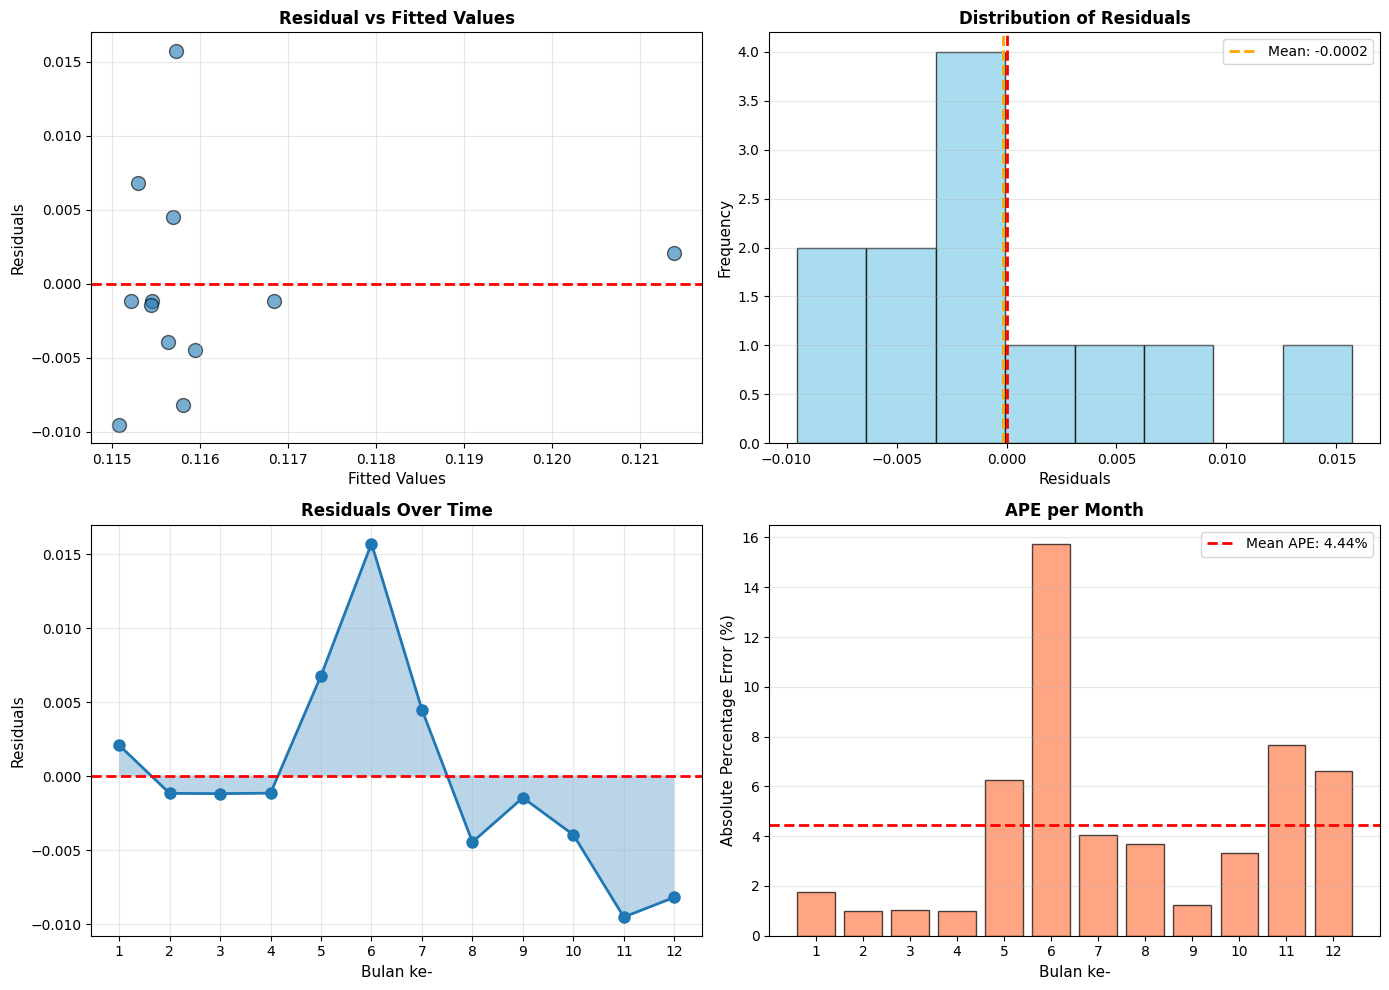

In [ ]:
# =========================================
# 4.6 EVALUASI MODEL HYBRID WT-ARIMA-XGBOOST
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns

print("="*60)
print("   4.6 EVALUASI MODEL HYBRID WAVELET–ARIMA–XGBOOST")
print("="*60)

# =========================================
# 4.6.1 EVALUASI TRAINING SET
# =========================================
print("\n📊 4.6.1 EVALUASI TRAINING SET")
print("-"*60)

# Prediksi pada training set
train_pred_trans = model_xgb.predict(X_train)
train_pred_inv = inv_boxcox(train_pred_trans, lambda_opt)
train_true_inv = inv_boxcox(y_train.values, lambda_opt)

# Metrik evaluasi training
train_mse = mean_squared_error(train_true_inv, train_pred_inv)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(train_true_inv, train_pred_inv)
train_mape = np.mean(np.abs((train_true_inv - train_pred_inv) / train_true_inv)) * 100
train_r2 = r2_score(train_true_inv, train_pred_inv)

print(f"MSE   : {train_mse:.6f}")
print(f"RMSE  : {train_rmse:.6f}")
print(f"MAE   : {train_mae:.6f}")
print(f"MAPE  : {train_mape:.2f}%")
print(f"R²    : {train_r2:.4f}")

# =========================================
# 4.6.2 EVALUASI TESTING SET (12 BULAN)
# =========================================
print("\n📊 4.6.2 EVALUASI TESTING SET (12 BULAN)")
print("-"*60)

# Metrik evaluasi testing (sudah dihitung sebelumnya)
test_mse = mean_squared_error(df_forecast['y_true_inv'], df_forecast['y_pred_inv'])
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(df_forecast['y_true_inv'], df_forecast['y_pred_inv'])
test_mape = np.mean(np.abs((df_forecast['y_true_inv'] - df_forecast['y_pred_inv']) / df_forecast['y_true_inv'])) * 100
test_r2 = r2_score(df_forecast['y_true_inv'], df_forecast['y_pred_inv'])

print(f"MSE   : {test_mse:.6f}")
print(f"RMSE  : {test_rmse:.6f}")
print(f"MAE   : {test_mae:.6f}")
print(f"MAPE  : {test_mape:.2f}%")
print(f"R²    : {test_r2:.4f}")

# =========================================
# 4.6.3 TABEL PERBANDINGAN METRIK
# =========================================
print("\n📋 4.6.3 TABEL PERBANDINGAN METRIK TRAIN vs TEST")
print("-"*60)

comparison_metrics = pd.DataFrame({
    'Metrik': ['MSE', 'RMSE', 'MAE', 'MAPE (%)', 'R²'],
    'Training': [train_mse, train_rmse, train_mae, train_mape, train_r2],
    'Testing': [test_mse, test_rmse, test_mae, test_mape, test_r2]
})

print(comparison_metrics.to_string(index=False))

# =========================================
# 4.6.4 TABEL HASIL FORECAST 12 BULAN
# =========================================
print("\n📋 4.6.4 TABEL HASIL FORECAST 12 BULAN KE DEPAN")
print("-"*60)

# Buat tabel lengkap dengan error metrics per bulan
forecast_table = pd.DataFrame({
    'Index': df_forecast.index,
    'Actual': df_forecast['y_true_inv'].values,
    'Forecast': df_forecast['y_pred_inv'].values,
    'Error': df_forecast['y_pred_inv'].values - df_forecast['y_true_inv'].values,
    'Abs_Error': np.abs(df_forecast['y_pred_inv'].values - df_forecast['y_true_inv'].values),
    'APE (%)': np.abs((df_forecast['y_true_inv'].values - df_forecast['y_pred_inv'].values) / df_forecast['y_true_inv'].values) * 100
})

forecast_table['Bulan_Ke'] = range(1, len(forecast_table) + 1)
forecast_table = forecast_table[['Bulan_Ke', 'Index', 'Actual', 'Forecast', 'Error', 'Abs_Error', 'APE (%)']]

print(forecast_table.to_string(index=False))

# Statistik error
print("\n📊 Statistik Error Forecast:")
print(f"Mean Error        : {forecast_table['Error'].mean():.6f}")
print(f"Std Error         : {forecast_table['Error'].std():.6f}")
print(f"Mean Abs Error    : {forecast_table['Abs_Error'].mean():.6f}")
print(f"Max Abs Error     : {forecast_table['Abs_Error'].max():.6f}")
print(f"Min Abs Error     : {forecast_table['Abs_Error'].min():.6f}")

# =========================================
# 4.6.5 VISUALISASI: PLOT FORECAST
# =========================================
print("\n📈 4.6.5 VISUALISASI HASIL FORECAST")
print("-"*60)

# Figure 1: Full View (Train + Test)
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: Full data overview
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(train.index, inv_boxcox(train['y_trans'], lambda_opt),
         label='Training Data', color='blue', linewidth=1.5, alpha=0.7)
ax1.plot(test.index, df_forecast['y_true_inv'],
         label='Actual Test', color='green', linewidth=2.5, marker='o', markersize=6)
ax1.plot(test.index, df_forecast['y_pred_inv'],
         label='Forecast', color='red', linewidth=2.5,
         linestyle='--', marker='s', markersize=6)
ax1.axvline(x=test.index[0], color='gray', linestyle=':', linewidth=2, alpha=0.5)
ax1.legend(loc='best', fontsize=11)
ax1.set_title('Model Hybrid WT–ARIMA–XGBoost: Full Data View', fontsize=13, fontweight='bold')
ax1.set_xlabel('Index', fontsize=11)
ax1.set_ylabel('Nilai', fontsize=11)
ax1.grid(alpha=0.3)

# Plot 2: Zoom in (36 bulan terakhir)
ax2 = fig.add_subplot(gs[1, :])
n_context = 36
train_context = train.iloc[-n_context:] if len(train) > n_context else train
ax2.plot(train_context.index, inv_boxcox(train_context['y_trans'], lambda_opt),
         label='Training (Last 36 months)', color='blue', linewidth=2, alpha=0.8)
ax2.plot(test.index, df_forecast['y_true_inv'],
         label='Actual Test', color='green', linewidth=3, marker='o', markersize=8)
ax2.plot(test.index, df_forecast['y_pred_inv'],
         label='Forecast', color='red', linewidth=3,
         linestyle='--', marker='s', markersize=8)
ax2.axvline(x=test.index[0], color='gray', linestyle=':', linewidth=2, alpha=0.5)
ax2.fill_between(test.index, df_forecast['y_true_inv'], df_forecast['y_pred_inv'],
                 alpha=0.2, color='orange')
ax2.legend(loc='best', fontsize=11)
ax2.set_title(f'Zoom In: Forecast Period (MAPE: {test_mape:.2f}%)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Index', fontsize=11)
ax2.set_ylabel('Nilai', fontsize=11)
ax2.grid(alpha=0.3)

# Plot 3: Test period only dengan error bars
ax3 = fig.add_subplot(gs[2, 0])
x_pos = range(1, len(test.index) + 1)
ax3.plot(x_pos, df_forecast['y_true_inv'],
         label='Actual', color='green', linewidth=2.5, marker='o', markersize=9)
ax3.plot(x_pos, df_forecast['y_pred_inv'],
         label='Forecast', color='red', linewidth=2.5,
         linestyle='--', marker='s', markersize=9)
for i in range(len(x_pos)):
    color = 'red' if forecast_table['Error'].iloc[i] > 0 else 'blue'
    ax3.plot([x_pos[i], x_pos[i]],
             [df_forecast['y_true_inv'].iloc[i], df_forecast['y_pred_inv'].iloc[i]],
             color=color, alpha=0.4, linewidth=2)
ax3.legend(loc='best', fontsize=10)
ax3.set_title('Forecast vs Actual (Test Period)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Bulan ke-', fontsize=10)
ax3.set_ylabel('Nilai', fontsize=10)
ax3.grid(alpha=0.3, linestyle='--')
ax3.set_xticks(x_pos)

# Plot 4: Error distribution
ax4 = fig.add_subplot(gs[2, 1])
colors = ['red' if e > 0 else 'blue' for e in forecast_table['Error']]
ax4.bar(x_pos, forecast_table['Error'], color=colors, alpha=0.6, edgecolor='black')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.axhline(y=forecast_table['Error'].mean(), color='orange',
            linestyle='--', linewidth=2, label=f'Mean Error: {forecast_table["Error"].mean():.4f}')
ax4.legend(loc='best', fontsize=10)
ax4.set_title('Forecast Error per Month', fontsize=12, fontweight='bold')
ax4.set_xlabel('Bulan ke-', fontsize=10)
ax4.set_ylabel('Error (Forecast - Actual)', fontsize=10)
ax4.grid(alpha=0.3, axis='y', linestyle='--')
ax4.set_xticks(x_pos)

plt.savefig('WT_ARIMA_XGBoost_Evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# =========================================
# 4.6.6 VISUALISASI: RESIDUAL ANALYSIS
# =========================================
print("\n📊 4.6.6 ANALISIS RESIDUAL")
print("-"*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residual vs Fitted
axes[0, 0].scatter(df_forecast['y_pred_inv'], forecast_table['Error'],
                   alpha=0.6, s=100, edgecolor='black')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values', fontsize=11)
axes[0, 0].set_ylabel('Residuals', fontsize=11)
axes[0, 0].set_title('Residual vs Fitted Values', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Histogram of residuals
axes[0, 1].hist(forecast_table['Error'], bins=8, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(x=forecast_table['Error'].mean(), color='orange',
                   linestyle='--', linewidth=2, label=f'Mean: {forecast_table["Error"].mean():.4f}')
axes[0, 1].set_xlabel('Residuals', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis='y')

# Plot 3: Residual plot (time series)
axes[1, 0].plot(x_pos, forecast_table['Error'], marker='o', linewidth=2, markersize=8)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].fill_between(x_pos, 0, forecast_table['Error'], alpha=0.3)
axes[1, 0].set_xlabel('Bulan ke-', fontsize=11)
axes[1, 0].set_ylabel('Residuals', fontsize=11)
axes[1, 0].set_title('Residuals Over Time', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xticks(x_pos)

# Plot 4: Absolute Percentage Error
axes[1, 1].bar(x_pos, forecast_table['APE (%)'], alpha=0.7, color='coral', edgecolor='black')
axes[1, 1].axhline(y=test_mape, color='red', linestyle='--', linewidth=2,
                   label=f'Mean APE: {test_mape:.2f}%')
axes[1, 1].set_xlabel('Bulan ke-', fontsize=11)
axes[1, 1].set_ylabel('Absolute Percentage Error (%)', fontsize=11)
axes[1, 1].set_title('APE per Month', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')
axes[1, 1].set_xticks(x_pos)

plt.tight_layout()
plt.savefig('WT_ARIMA_XGBoost_Residuals.png', dpi=300, bbox_inches='tight')
plt.show()
